## Web Crawling
- 웹 페이지에서 데이터를 수집하는 방법에 대해서 학습

### 웹크롤링 방법

#### 웹페이지의 종류
- 정적인 페이지 : 웹 브라우져에 화면이 한번 뜨면 이벤트에 의한 화면의 변경이 없는 페이지 
- 동적인 페이지 : 웹 브라우져에 화면이 뜨고 이벤트가 발생하면 서버에서 데이터를 가져와 화면을 변경하는 페이지

#### requests 이용
- 받아오는 문자열에 따라 두가지 방법으로 구분
    - json 문자열로 받아서 파싱하는 방법 : 주로 동적 페이지 크롤링할때 사용 
    - html 문자열로 받아서 파싱하는 방법 : 주로 정적 페이지 크롤링할때 사용
        
#### selenium 이용
- 브라우져를 직접 열어서 데이터를 받는 방법

#### 크롤링 방법에 따른 속도
- requests json > requests html > selenium

### Crawling Naver Stock Datas
- 네이버 증권 사이트에서 주가 데이터 수집
- 수집할 데이터 : 일별 kospi, kosdaq 주가, 일별 환율(exchange rate) 데이터
- 데이터 수집 절차
    - 웹서비스 분석 : url - chrome devtool
    - 서버에 데이터 요청 : request(url) > response : json(str)
    - 서버에서 받은 데이터 파싱(데이터 형태를 변경) : json(str) > list, dict > DataFrame

In [5]:
import requests
import pandas as pd

#### 1. 웹서비스 분석 : url
- pc 웹페이지가 복잡하면 mobile 웹페이지에서 수집

In [51]:
page_size, page = 60, 1 # page_size가 60 초과일 경우 400 오류 발생
url = f'https://m.stock.naver.com/api/index/KOSPI/price?pageSize={page_size}&page{page}'

#### 2. 서버에 데이터 요청 : request(url) > response : json(str)
- response의 status code가 200이 나오는지 확인
- 403이나 500이 나오면 request가 잘못되거나 web server에서 수집이 안되도록 설정이 된것임
    - header 설정 또는 selenium 사용
- 200이 나오더라도 response 안에 있는 내용을 확인 > 확인하는 방법 : response.text

In [54]:
response = requests.get(url)

response

<Response [200]>

#### 3. 서버에서 받은 데이터 파싱(데이터 형태를 변경) : json(str) > list, dict > DataFrame

In [57]:
stock_json = response.json()

type(stock_json)

list

In [59]:
df = pd.DataFrame(stock_json)
df = df[['localTradedAt', 'closePrice']]
df

,localTradedAt,closePrice
0,2024-09-19,"2,580.80"
1,2024-09-13,"2,575.41"
2,2024-09-12,"2,572.09"
3,2024-09-11,"2,513.37"
4,2024-09-10,"2,523.43"
5,2024-09-09,"2,535.93"
6,2024-09-06,"2,544.28"
7,2024-09-05,"2,575.50"
8,2024-09-04,"2,580.80"
9,2024-09-03,"2,664.63"


#### 4. 함수로 만들기

In [51]:
page_size, page = 60, 1 # page_size가 60 초과일 경우 400 오류 발생
url = f'https://m.stock.naver.com/api/index/KOSPI/price?pageSize={page_size}&page{page}'

In [1]:
def stock_price(item, page = 1, page_size = 60):
    url = f'https://m.stock.naver.com/api/index/{item}/price?pageSize={page_size}&page{page}'
    response = requests.get(url)
    stock_json = response.json()
    df = pd.DataFrame(stock_json)[['localTradedAt', 'closePrice']]
    return df

In [9]:
stock_price('KOSDAQ', page = 2, page_size=5)

,localTradedAt,closePrice
0,2024-09-20,750.32
1,2024-09-19,739.51
2,2024-09-13,733.20
3,2024-09-12,731.03
4,2024-09-11,709.42


#### 5. 원달러 환율 데이터 수집 : 실습

In [29]:
url = 'https://m.stock.naver.com/front-api/marketIndex/prices?category=exchange&reutersCode=FX_USDKRW&pageSize=20&page=1'

response = requests.get(url)
data = response.json()['result']
df = pd.DataFrame(data)[['localTradedAt', 'closePrice']]
df

,localTradedAt,closePrice
0,2024-09-20,"1,330.90"
1,2024-09-19,"1,330.00"
2,2024-09-13,"1,332.00"
3,2024-09-12,"1,339.00"
4,2024-09-11,"1,340.50"
5,2024-09-10,"1,344.50"
6,2024-09-09,"1,342.00"
7,2024-09-06,"1,339.50"
8,2024-09-05,"1,335.00"
9,2024-09-04,"1,336.50"


In [35]:
def exchange(code, page = 1, page_size = 20):
    url = f'https://m.stock.naver.com/front-api/marketIndex/prices?category=exchange&reutersCode=FX_{code}&page={page}&pageSize={page_size}'
    response = requests.get(url)
    data = response.json()['result']
    df = pd.DataFrame(data)[['localTradedAt', 'closePrice']]
    return df

In [47]:
exchange('TWDKRW')

,localTradedAt,closePrice
0,2024-09-20,41.73
1,2024-09-19,41.64
2,2024-09-13,41.68
3,2024-09-12,41.74
4,2024-09-11,41.69
5,2024-09-10,41.77
6,2024-09-09,41.78
7,2024-09-06,41.81
8,2024-09-05,41.66
9,2024-09-04,41.65


#### 6. 시각화

In [63]:
page_size = 30
kp_df = stock_price('KOSPI', page_size = page_size)
kd_df = stock_price('KOSDAQ', page_size = page_size)
usd_df = exchange('USDKRW', page_size = page_size)

# 종가 데이터 숫자 형태로 변환
# 1,604.07 을 1604.07로 변환
kp_df['closePrice'] = kp_df['closePrice'].apply(lambda data: float(data.replace(',', '')))
kd_df['closePrice'] = kd_df['closePrice'].apply(lambda data: float(data.replace(',', '')))
usd_df['closePrice'] = usd_df['closePrice'].apply(lambda data: float(data.replace(',', '')))
usd_df

,localTradedAt,closePrice
0,2024-09-20,1330.5
1,2024-09-19,1330.0
2,2024-09-13,1332.0
3,2024-09-12,1339.0
4,2024-09-11,1340.5
5,2024-09-10,1344.5
6,2024-09-09,1342.0
7,2024-09-06,1339.5
8,2024-09-05,1335.0
9,2024-09-04,1336.5


<function matplotlib.pyplot.show(close=None, block=None)>

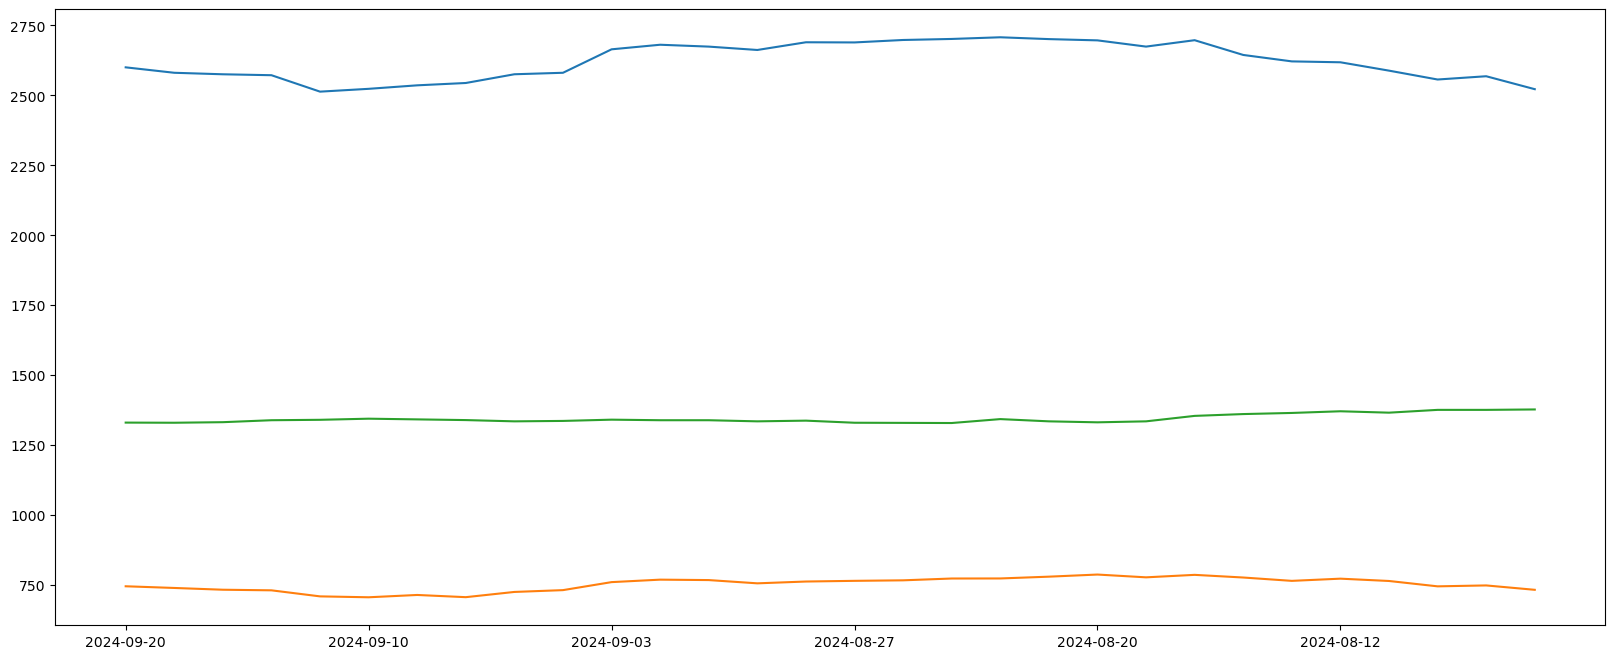

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize = (20, 8))
plt.plot(kp_df['localTradedAt'], kp_df['closePrice'], label='KOSPI')
plt.plot(kd_df['localTradedAt'], kd_df['closePrice'], label='KOSDAQ')
plt.plot(usd_df['localTradedAt'], usd_df['closePrice'], label='USD')
plt.legend
plt.xticks(kp_df['localTradedAt'][::5])
plt.show

#### 7. 데이터 스케일링
- min max scaling


- $z = \frac{x_i - min(x)}{max(x) - min(x)} (0 \leqq z \leqq 1)$


- latex syntax : `https://jjycjnmath.tistory.com/117`

In [81]:
from sklearn.preprocessing import minmax_scale

<function matplotlib.pyplot.show(close=None, block=None)>

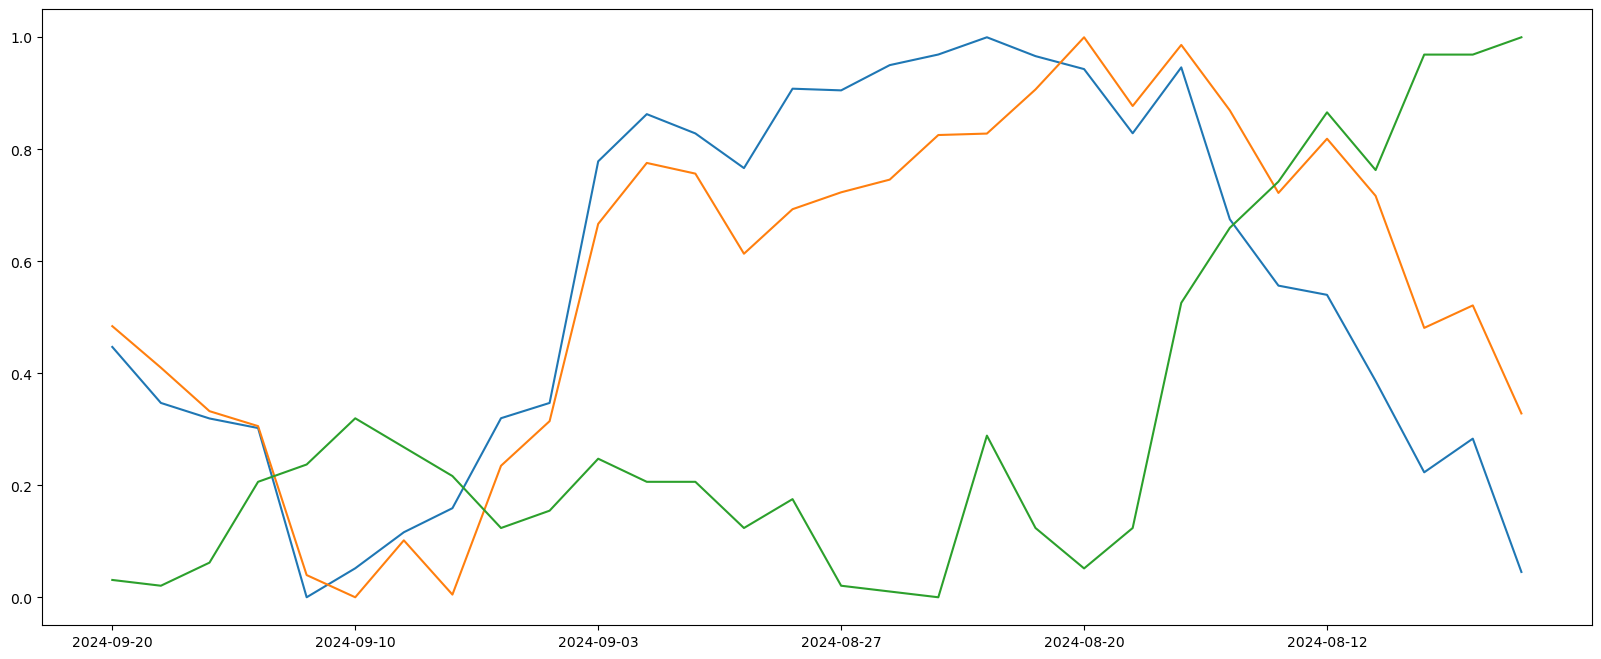

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize = (20, 8))
plt.plot(kp_df['localTradedAt'], minmax_scale(kp_df['closePrice']), label='KOSPI')
plt.plot(kd_df['localTradedAt'], minmax_scale(kd_df['closePrice']), label='KOSDAQ')
plt.plot(usd_df['localTradedAt'], minmax_scale(usd_df['closePrice']), label='USD')
plt.legend
plt.xticks(kp_df['localTradedAt'][::5])
plt.show

#### 8. 상관관계 분석
- 피어슨 상관계수(Pearson Correlation Coefficient)
- 두 데이터 집합의 상관도를 분석할때 사용되는 지표
- 상관계수의 해석
    - -1에 가까울수록 서로 반대방향으로 움직임
    - 1에 가까울수록 서로 같은방향으로 움직임
    - 0에 가까울수록 두 데이터는 관계가 없음

In [87]:
merge_df = pd.merge(kp_df, kd_df, on = 'localTradedAt')
merge_df = pd.merge(merge_df, usd_df, on = 'localTradedAt')
merge_df.columns = ['date', 'kospi', 'kosdaq', 'usd']

merge_df

,date,kospi,kosdaq,usd
0,2024-09-20,2600.23,745.53,1330.5
1,2024-09-19,2580.80,739.51,1330.0
2,2024-09-13,2575.41,733.20,1332.0
3,2024-09-12,2572.09,731.03,1339.0
4,2024-09-11,2513.37,709.42,1340.5
5,2024-09-10,2523.43,706.20,1344.5
6,2024-09-09,2535.93,714.46,1342.0
7,2024-09-06,2544.28,706.59,1339.5
8,2024-09-05,2575.50,725.28,1335.0
9,2024-09-04,2580.80,731.75,1336.5


In [89]:
merge_df.iloc[:, 1:].corr()

,kospi,kosdaq,usd
kospi,1.000000,0.881709,-0.356208
kosdaq,0.881709,1.000000,0.031461
usd,-0.356208,0.031461,1.000000
